# EDA — Разведывательный анализ данных

Исследуем поведение клиентов оптики по следующим направлениям:

## A. Общая аналитика
- Количество клиентов по годам
- Рост базы клиентов
- Сезонность
- Динамика продаж

## B. Анализ категорий
- Популярность услуг: очки, линзы, проверка зрения, продажа, ремонт

## C. Retention Analysis
- Сколько клиентов вернулись повторно
- Через сколько дней возвращаются
- Какие услуги приводят к retention


In [1]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "seaborn"])



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'matplotlib', 'seaborn'], returncode=0)

In [2]:
pip install notebook


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
\



(42085, 7)
               Дата     Номер_чека        Категория Сумма_без_скидки  \
0  10.08.2022 13:18  1 000 103 543   Контакт. линзы         2 990,00   
1  30.07.2022 13:54  1 000 102 002  Проверка зрения         1 500,00   
2  13.09.2022 15:59  1 000 108 272  Изготовл. очков        17 417,00   

  Сумма_со_скидкой                       customer_id  Возраст  
0         2 990,00  0ea171e97a5b685940db5644a0595da1     31.0  
1                0  02c8d6f1f933b38c2213bee3e3b3c7ae     70.0  
2        15 970,00  d6bcd8202ef91bf75d7ca0793eca405e     68.0  


Анализируем динамику визитов по годам, чтобы понять растёт или падает поток клиентов.

In [4]:
#вытаскиваем год для анализа "Количество клиентов по годам"
df["Год"] = df["Дата"].str.split(".").str[2].str.split(" ").str[0]
print(df["Год"].value_counts().sort_index())
года = df["Год"].value_counts().sort_index()

Год
2020    6719
2021    7616
2022    7651
2023    7392
2024    6340
2025    5379
2026     988
Name: count, dtype: int64


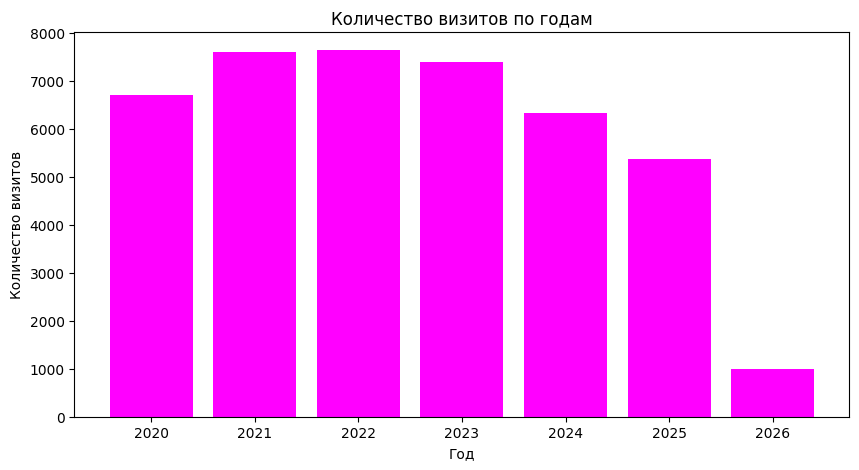

In [5]:
#строим график
plt.figure(figsize=(10, 5))
plt.bar(года.index, года.values, color="magenta")
plt.title("Количество визитов по годам")
plt.xlabel("Год")
plt.ylabel("Количество визитов")
plt.xticks(rotation=0)
plt.show()

График показывает динамику визитов по годам. Заметно плавное снижение потока клиентов с 2021 года. Данные за 2026 год неполные — только до мая

Анализируем динамику визитов по месяцам, чтобы понять есть ли сезонность в потоке клиентов оптики

In [6]:
#вытаскиваем месяц для анализа "Сезонность"
df["Месяц"] = df["Дата"].str.split(".").str[1]
print(df["Месяц"].value_counts().sort_index())
месяца = df["Месяц"].value_counts().sort_index()



Месяц
01    2968
02    3141
03    2943
04    3006
05    3624
06    3822
07    4159
08    4491
09    3849
10    3812
11    3396
12    2874
Name: count, dtype: int64


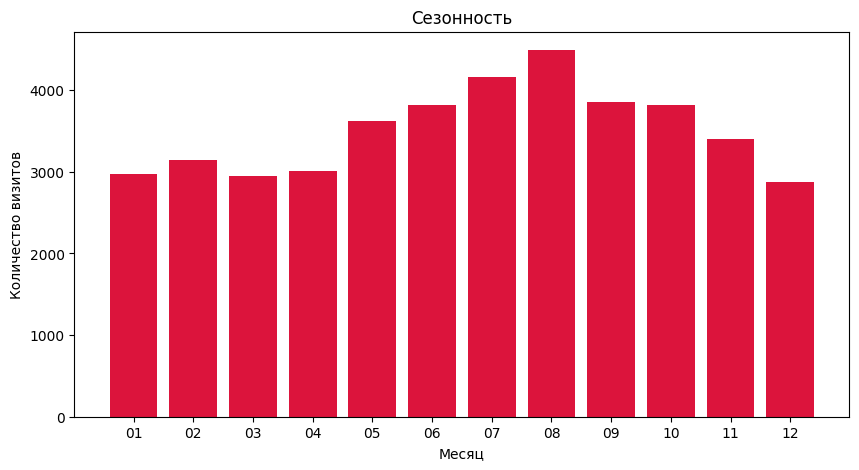

In [7]:
#строим график

plt.figure(figsize=(10, 5))
plt.bar(месяца.index, месяца.values, color="crimson")
plt.title("Сезонность")
plt.xlabel("Месяц")
plt.ylabel("Количество визитов")
plt.xticks(rotation=0)
plt.show()

Выявлена чёткая сезонность: пик визитов приходится на летние месяцы (июнь-август), минимум — в декабре-январе. Вероятная причина: подготовка детей к школе и летняя активность клиентов.

Анализируем рост уникальных клиентов по годам. 

In [8]:
#вытаскиваем уникальных клиентов по годам
клиенты_по_годам = df.groupby("Год")["customer_id"].nunique()
print(клиенты_по_годам)

Год
2020    4326
2021    5156
2022    5519
2023    5656
2024    4638
2025    3995
2026     710
Name: customer_id, dtype: int64


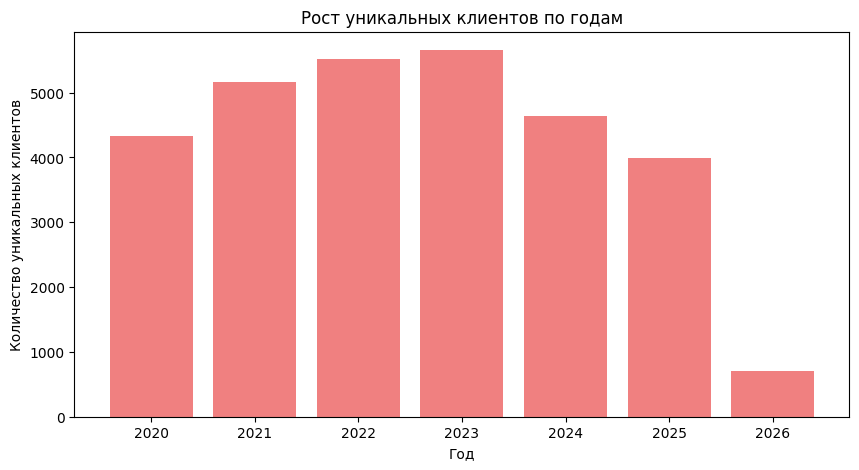

In [9]:
##строим график
plt.figure(figsize=(10, 5)) 
plt.bar(клиенты_по_годам.index, клиенты_по_годам.values, color="lightcoral") 
plt.title("Рост уникальных клиентов по годам") 
plt.xlabel("Год") 
plt.ylabel("Количество уникальных клиентов") 
plt.xticks(rotation=0) 
plt.show()

База росла до 2023 года (пик — 5 656 клиентов), после чего наблюдается снижение. Данные за 2026 год неполные — только до мая."

Анализируем динамику продаж

In [10]:
#Cоздаём колонку Сумма_чистая из Сумма_со_скидкой — именно эта сумма поступает на кассу. 
# Преобразуем строки в числа: убираем пробелы, заменяем запятую на точку, переводим в float.
df["Сумма_чистая"] = df["Сумма_со_скидкой"].str.replace(" ", "").str.replace(",", ".").astype(float)
print(df["Сумма_чистая"].head(5))

0     2990.0
1        0.0
2    15970.0
3     6775.0
4     1950.0
Name: Сумма_чистая, dtype: float64


In [11]:
#Считаем суммарную выручку по годам для анализа динамики продаж
выручка_по_годам = df.groupby("Год")["Сумма_чистая"].sum()
print(выручка_по_годам)

Год
2020    39130485.23
2021    56250206.56
2022    66892579.75
2023    67546274.00
2024    59256019.70
2025    55802085.00
2026    11505042.00
Name: Сумма_чистая, dtype: float64


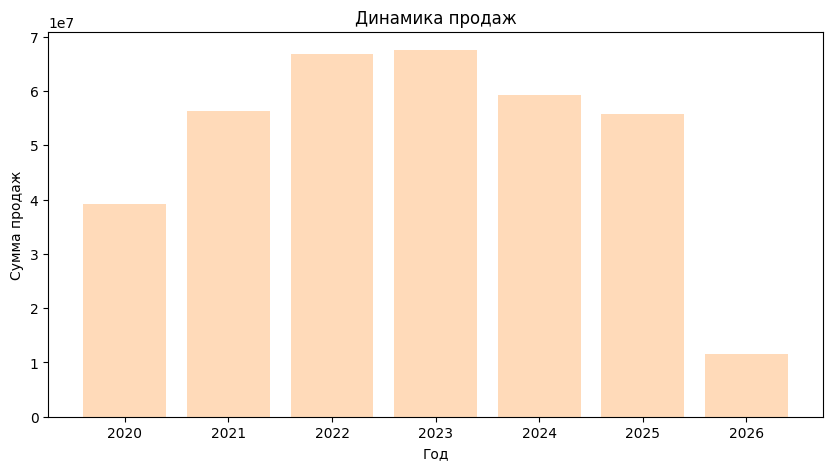

In [12]:
##строим график
plt.figure(figsize=(10, 5)) 
plt.bar(выручка_по_годам.index, выручка_по_годам.values, color="peachpuff") 
plt.title("Динамика продаж") 
plt.xlabel("Год") 
plt.ylabel("Сумма продаж") 
plt.xticks(rotation=0) 
plt.show()

Выручка росла до 2023 года (пик — ~70 млн тенге), после чего наблюдается снижение. Динамика совпадает с падением числа клиентов. Возможные причины: открытие конкурирующих сетевых оптик с бесплатной проверкой зрения, снижение рекламной активности собственной сети.

Анализируем популярность категорий услуг, чтобы понять какие направления приносят больше всего визитов и на что делать упор в маркетинге

In [13]:
категории = df["Категория"].value_counts()
print(категории)

Категория
Проверка зрения    20762
Изготовл. очков    17129
Контакт. линзы      2348
Продажа             1833
Ремонт                13
Name: count, dtype: int64


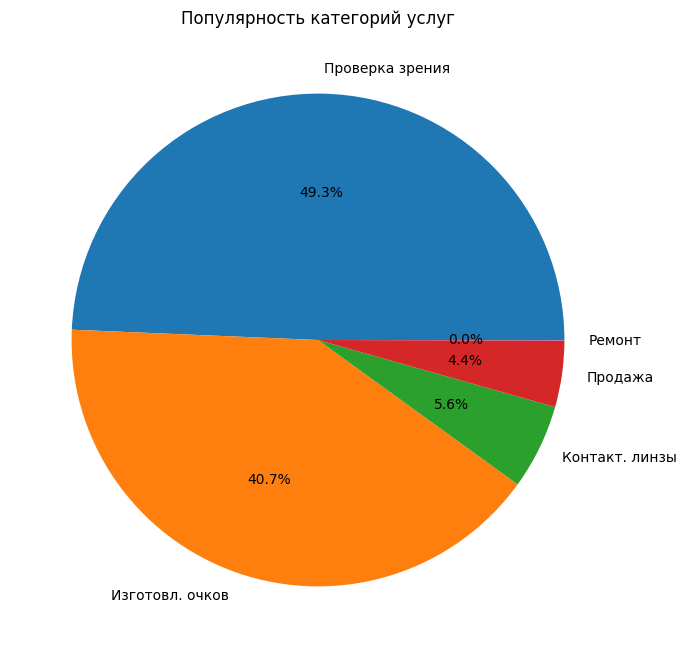

In [14]:
#строим график
plt.figure(figsize=(8, 8))
plt.pie(категории.values, labels=категории.index, autopct="%1.1f%%")
plt.title("Популярность категорий услуг")
plt.show()

Основную долю визитов занимают проверка зрения (49.6%) и изготовление очков (40.7%) — это ядро бизнеса оптики. Категория контактных линз (5.5%) имеет потенциал для роста — стоит усилить рекламу именно в этом направлении.

Retention Analysis — анализ возвращаемости клиентов. Считаем какой процент клиентов вернулся повторно после первого визита. Важно учитывать специфику: для проверки зрения и очков нормальный цикл возврата — 1 раз в год, для продажи контактных линз — 1 раз в месяц-полтора.

In [15]:
#находим дату первого визита для каждого ID
df["Дата"] = pd.to_datetime(df["Дата"], dayfirst=True)
первый_визит = df.groupby("customer_id")["Дата"].min().reset_index()
первый_визит.columns = ["customer_id", "первый_визит"]
print(первый_визит.head(5))

                        customer_id        первый_визит
0  00008f456af0350d1bc645da8f8a4c25 2022-10-14 14:14:00
1  00067877bd7ebf0c1fd6efa81aca1de0 2022-08-18 12:36:00
2  0007340ae2b5bb4fdfbb26de15e148f5 2022-12-28 12:44:00
3  000db87d70b05184f7be5578709b07a2 2023-04-11 10:37:00
4  000fb62cd4bade868a372390d03a1cfe 2024-03-24 14:27:00


In [16]:
#находим дату повторного визита для каждого ID
второй_визит = df.groupby("customer_id")["Дата"].apply(
    lambda x: sorted(x)[1] if len(x) > 1 else None
).reset_index()
второй_визит.columns = ["customer_id", "второй_визит"]
print(второй_визит.head(5))

                        customer_id        второй_визит
0  00008f456af0350d1bc645da8f8a4c25                 NaT
1  00067877bd7ebf0c1fd6efa81aca1de0                 NaT
2  0007340ae2b5bb4fdfbb26de15e148f5                 NaT
3  000db87d70b05184f7be5578709b07a2 2023-04-11 10:51:00
4  000fb62cd4bade868a372390d03a1cfe                 NaT


In [17]:
#высчитываем общий Ретеншн
retention = первый_визит.merge(второй_визит, on="customer_id")
вернулись = retention["второй_визит"].notna().sum()
всего = len(retention)
процент = round(вернулись / всего * 100, 1)

print(f"Всего клиентов: {всего}")
print(f"Вернулись: {вернулись}")
print(f"Retention rate: {процент}%")

Всего клиентов: 29538
Вернулись: 9837
Retention rate: 33.3%


Retention rate составляет 33.3% — только каждый третий клиент возвращается повторно. Для оптики это низкий показатель, особенно учитывая что проверка зрения рекомендуется ежегодно, а пользователи контактных линз должны возвращаться ежемесячно. Это указывает на проблему с удержанием клиентов и необходимость работы с лояльностью. Основная проблема retention в оптике — длинный цикл возврата. Очки меняют раз в 1-3 года, проверка зрения — ещё реже. Единственный продукт с коротким циклом возврата — контактные линзы (раз в месяц-полтора). При retention МКЛ всего 15.8% сеть теряет самый перспективный источник регулярного дохода. Стратегическая рекомендация: усилить продвижение МКЛ как основного инструмента удержания клиентов.

In [18]:
# определяем возвращаемость по категориям
первая_категория = df.sort_values("Дата").groupby("customer_id")["Категория"].first().reset_index()
первая_категория.columns = ["customer_id", "первая_категория"]
print(первая_категория.head(5))

                        customer_id первая_категория
0  00008f456af0350d1bc645da8f8a4c25  Проверка зрения
1  00067877bd7ebf0c1fd6efa81aca1de0  Проверка зрения
2  0007340ae2b5bb4fdfbb26de15e148f5  Изготовл. очков
3  000db87d70b05184f7be5578709b07a2  Проверка зрения
4  000fb62cd4bade868a372390d03a1cfe  Изготовл. очков


In [19]:
retention = retention.merge(первая_категория, on="customer_id")

retention_по_категориям = retention.groupby("первая_категория").apply(
    lambda x: round(x["второй_визит"].notna().sum() / len(x) * 100, 1)
).reset_index()
retention_по_категориям.columns = ["Категория", "Retention_%"]
print(retention_по_категориям)

         Категория  Retention_%
0  Изготовл. очков         28.1
1   Контакт. линзы         15.7
2  Проверка зрения         38.7
3          Продажа         17.0
4           Ремонт        100.0


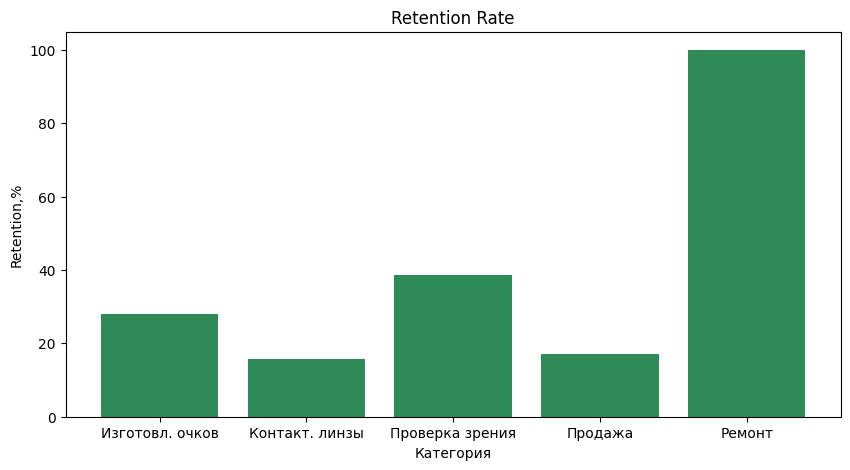

In [20]:
##строим график
plt.figure(figsize=(10, 5)) 
plt.bar(retention_по_категориям["Категория"], retention_по_категориям["Retention_%"], color="seagreen") 
plt.title("Retention Rate") 
plt.xlabel("Категория") 
plt.ylabel("Retention,%") 
plt.xticks(rotation=0) 
plt.show()

Retention по категориям показывает критическую проблему: клиенты МКЛ возвращаются только в 15.8% случаев, при том что нормальный цикл покупки контактных линз — раз в месяц-полтора. Это означает что сеть теряет регулярных покупателей МКЛ в пользу конкурентов. Это ключевая точка роста для бизнеса.

In [21]:
первый_визит["год_первого"] = первый_визит["первый_визит"].dt.year

новые_по_годам = первый_визит.groupby("год_первого")["customer_id"].count()
print(новые_по_годам)

год_первого
2020    4326
2021    5078
2022    5427
2023    5547
2024    4542
2025    3926
2026     692
Name: customer_id, dtype: int64


In [22]:
df2 = df.merge(первый_визит[["customer_id", "год_первого"]], on="customer_id")
df2["тип_клиента"] = df2.apply(
    lambda row: "Новый" if str(row["год_первого"]) == row["Год"] else "Постоянный", axis=1
)

In [23]:
итог = df2.groupby(["Год", "тип_клиента"])["customer_id"].nunique().unstack().fillna(0)
print(итог)

тип_клиента   Новый  Постоянный
Год                            
2020         4326.0         0.0
2021         5078.0        78.0
2022         5427.0        92.0
2023         5547.0       109.0
2024         4542.0        96.0
2025         3926.0        69.0
2026          692.0        18.0


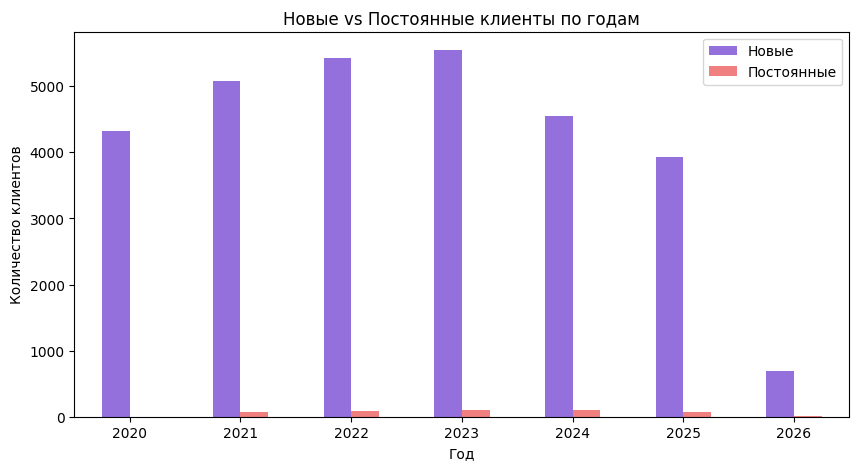

In [24]:
итог.plot(kind="bar", figsize=(10, 5), color=["mediumpurple", "lightcoral"])
plt.title("Новые vs Постоянные клиенты по годам")
plt.xlabel("Год")
plt.ylabel("Количество клиентов")
plt.xticks(rotation=0)
plt.legend(["Новые", "Постоянные"])
plt.show()

График показывает что подавляющее большинство клиентов каждый год — новые. Постоянных (вернувшихся в другой год) крайне мало, что подтверждает длинный цикл возврата в оптике

Анализируем визиты по дням недели и часам

In [25]:
порядок = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
дни = df['Дата'].dt.day_name().value_counts().reindex(порядок)

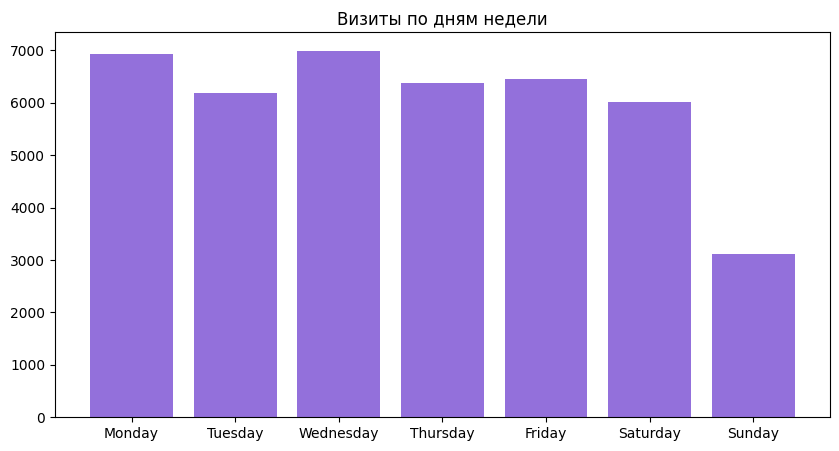

In [26]:
#строим график
plt.figure(figsize=(10, 5)) 
plt.bar(дни.index, дни.values, color="mediumpurple")
plt.title("Визиты по дням недели")
plt.xticks(rotation=0) 
plt.show()

Понедельник и среда — самые популярные дни (7359 и 7369 визитов). Воскресенье — значительный спад (3252 визита). В воскресенье и праздничные дни работает один сотрудник из-за низкого потока. Однако это точка роста: целенаправленные акции и скидки в выходные дни могут привлечь дополнительных клиентов и выровнять нагрузку по неделе.

In [27]:
df["weekday"] = df["Дата"].dt.day_name()
df["hour"] = df["Дата"].dt.hour
print(df[["Дата", "weekday", "hour"]].head(5))

                 Дата    weekday  hour
0 2022-08-10 13:18:00  Wednesday    13
1 2022-07-30 13:54:00   Saturday    13
2 2022-09-13 15:59:00    Tuesday    15
3 2020-04-24 17:44:00     Friday    17
4 2022-04-06 15:46:00  Wednesday    15


In [28]:
hour = df["hour"].value_counts().sort_index()
print (hour)

hour
8       62
9     1556
10    4092
11    5756
12    5841
13    4438
14    5498
15    5596
16    5121
17    3119
18     883
19     119
20       4
Name: count, dtype: int64


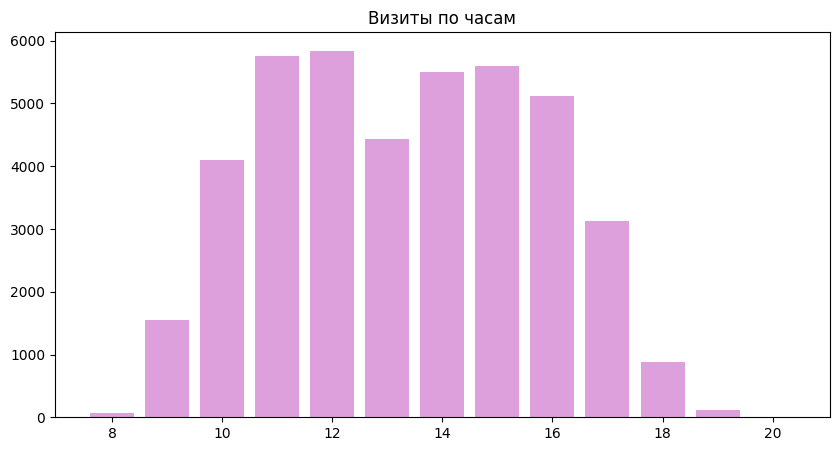

In [29]:
#строим график по часам
plt.figure(figsize=(10, 5)) 
plt.bar(hour.index, hour.values, color="plum")
plt.title("Визиты по часам")
plt.xticks(rotation=0) 
plt.show()

Пик визитов — 11:00-12:00: клиенты успевают сделать утренние дела и посетить оптику в рабочий день отпуска или по скользящему графику. Небольшой спад в 13:00 — обеденный перерыв. После 18:00 резкий спад — рабочий день заканчивается.

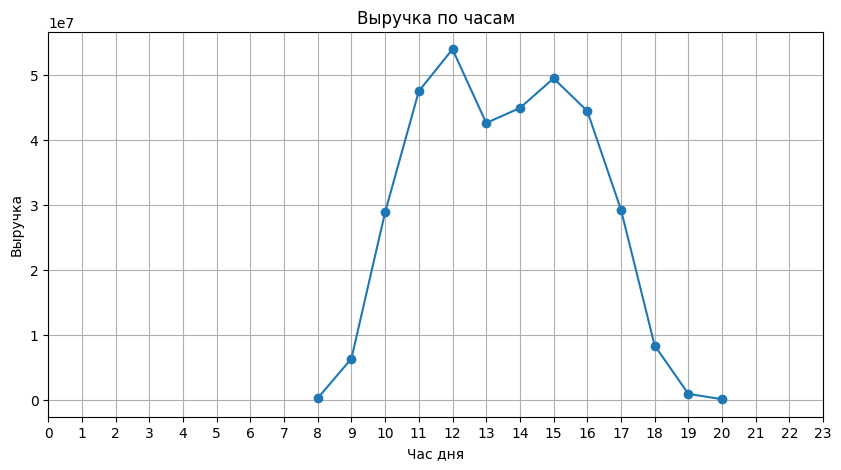

In [30]:
выручка_по_часам = (df.groupby("hour")["Сумма_чистая"].sum())

plt.figure(figsize=(10, 5))
plt.plot(выручка_по_часам.index, выручка_по_часам.values, marker="o")

plt.title("Выручка по часам")
plt.xlabel("Час дня")
plt.ylabel("Выручка")

plt.xticks(range(24))
plt.grid(True)
plt.show()

Высчитываем RFM

In [31]:
# берём дату последнего визита
последний_визит = df.groupby("customer_id")["Дата"].max().reset_index()
последний_визит.columns = ["customer_id", "последний_визит"]
print(последний_визит.head(3))

                        customer_id     последний_визит
0  00008f456af0350d1bc645da8f8a4c25 2022-10-14 14:14:00
1  00067877bd7ebf0c1fd6efa81aca1de0 2022-08-18 12:36:00
2  0007340ae2b5bb4fdfbb26de15e148f5 2022-12-28 12:44:00


In [32]:
дата_отсчёта = df["Дата"].max()

rfm = df.groupby("customer_id").agg(
    Recency=("Дата", lambda x: (дата_отсчёта - x.max()).days),
    Frequency=("customer_id", "count"),
    Monetary=("Сумма_чистая", "sum")
).reset_index()

print(rfm.head(5))

                        customer_id  Recency  Frequency  Monetary
0  00008f456af0350d1bc645da8f8a4c25     1298          1    3000.0
1  00067877bd7ebf0c1fd6efa81aca1de0     1355          1    2000.0
2  0007340ae2b5bb4fdfbb26de15e148f5     1223          1   33267.0
3  000db87d70b05184f7be5578709b07a2     1119          2   22907.0
4  000fb62cd4bade868a372390d03a1cfe      770          1   19410.0


In [33]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

print(rfm.head(5))

                        customer_id  Recency  Frequency  Monetary R_score  \
0  00008f456af0350d1bc645da8f8a4c25     1298          1    3000.0       3   
1  00067877bd7ebf0c1fd6efa81aca1de0     1355          1    2000.0       3   
2  0007340ae2b5bb4fdfbb26de15e148f5     1223          1   33267.0       3   
3  000db87d70b05184f7be5578709b07a2     1119          2   22907.0       3   
4  000fb62cd4bade868a372390d03a1cfe      770          1   19410.0       4   

  F_score M_score RFM_score  
0       1       2       312  
1       1       1       311  
2       1       5       315  
3       4       5       345  
4       1       4       414  


In [34]:
def сегмент(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])
    
    if r >= 4 and f >= 4 and m >= 4:
        return "VIP"
    elif r >= 3 and f >= 3:
        return "Лояльные"
    elif r >= 4 and f <= 2:
        return "Новые"
    elif r <= 2 and f >= 3:
        return "Под риском"
    elif r <= 2 and f <= 2:
        return "Потерянные"
    else:
        return "Спящие"

rfm["Сегмент"] = rfm.apply(сегмент, axis=1)
print(rfm["Сегмент"].value_counts())

Сегмент
Под риском    7459
Лояльные      6947
Новые         4934
Потерянные    4341
VIP           3317
Спящие        2540
Name: count, dtype: int64


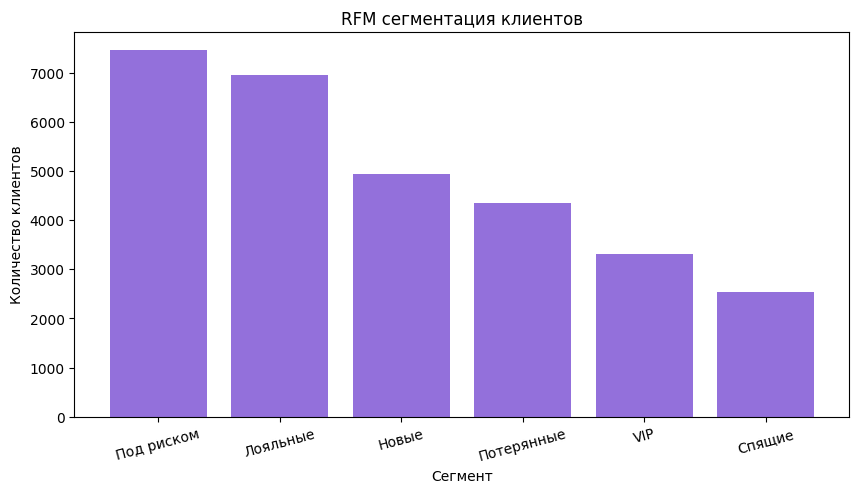

In [35]:
сегменты = rfm["Сегмент"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(сегменты.index, сегменты.values, color="mediumpurple")
plt.title("RFM сегментация клиентов")
plt.xlabel("Сегмент")
plt.ylabel("Количество клиентов")
plt.xticks(rotation=15)
plt.show()

RFM сегментация показала что самый большой сегмент — 'Под риском' (7461 клиентов): они приходили часто, но давно не возвращались. 
Рекомендации:
Под риском и Потерянные — персональные акции и напоминания о проверке зрения
Особый фокус на МКЛ — клиенты линз должны возвращаться ежемесячно, таргетированные предложения помогут удержать их
VIP (3315) — программа лояльности для удержания лучших клиентов
Новые (4934) — onboarding: рассказать про линзы и преимущества регулярных осмотров

In [36]:
rfm.to_csv("/Users/valentinayerokhina/Desktop/MyPythonProjects/Capstone/Data/Cleaned/rfm_segments.csv", index=False)
print("Сохранено!")

Сохранено!


In [37]:
# Готовим помесячную выручку
df["Дата"] = pd.to_datetime(df["Дата"], dayfirst=True)
df["Год"] = df["Дата"].dt.year
df["Месяц"] = df["Дата"].dt.month

выручка_по_месяцам = df.groupby(["Год", "Месяц"])["Сумма_чистая"].sum().reset_index()
выручка_по_месяцам.columns = ["Год", "Месяц", "Выручка"]
print(выручка_по_месяцам.head(10))

    Год  Месяц     Выручка
0  2020      4   634633.26
1  2020      5  4886540.21
2  2020      6  4720685.14
3  2020      7  5171109.45
4  2020      8  5682371.28
5  2020      9  4915920.29
6  2020     10  4842806.19
7  2020     11  4060919.00
8  2020     12  4215500.41
9  2021      1  4837323.00


In [38]:
# Считаем среднюю выручку по каждому месяцу за 2021–2025
сезонность = (
    выручка_по_месяцам[выручка_по_месяцам["Год"].between(2021, 2025)]
    .groupby("Месяц")["Выручка"]
    .mean()
)

# Фактическая выручка 2026 (январь–май)
факт_2026 = выручка_по_месяцам[выручка_по_месяцам["Год"] == 2026].set_index("Месяц")["Выручка"]

# Прогноз на июнь–декабрь 2026 из сезонности
прогноз_месяцы = [м for м in range(6, 13) if м not in факт_2026.index]
прогноз_сезон = сезонность[прогноз_месяцы]

print("Факт 2026 (янв–май):")
print(факт_2026)
print("\nПрогноз 2026 (июн–дек, сезонный):")
print(прогноз_сезон.round(0))

Факт 2026 (янв–май):
Месяц
1    3539776.0
2    3541260.0
3    3283910.0
4    1094716.0
5      45380.0
Name: Выручка, dtype: float64

Прогноз 2026 (июн–дек, сезонный):
Месяц
6     4998308.0
7     5701598.0
8     6353114.0
9     5522934.0
10    5129306.0
11    5075366.0
12    4181910.0
Name: Выручка, dtype: float64


In [39]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Берём только полные годы 2021–2025, строим по номеру месяца нарастающим итогом
df_trend = выручка_по_месяцам[выручка_по_месяцам["Год"].between(2021, 2025)].copy()
df_trend["период"] = (df_trend["Год"] - 2021) * 12 + df_trend["Месяц"]

X = df_trend["период"].values.reshape(-1, 1)
y = df_trend["Выручка"].values

модель = LinearRegression()
модель.fit(X, y)

# Прогнозируем июнь–декабрь 2026
периоды_прогноз = np.array([(2026 - 2021) * 12 + м for м in range(6, 13)]).reshape(-1, 1)
прогноз_линейный = модель.predict(периоды_прогноз)

print("Прогноз 2026 (июн–дек, линейный):")
for м, п in zip(range(6, 13), прогноз_линейный):
    print(f"  Месяц {м}: {п:,.0f} тенге")

Прогноз 2026 (июн–дек, линейный):
  Месяц 6: 4,916,469 тенге
  Месяц 7: 4,911,418 тенге
  Месяц 8: 4,906,367 тенге
  Месяц 9: 4,901,316 тенге
  Месяц 10: 4,896,264 тенге
  Месяц 11: 4,891,213 тенге
  Месяц 12: 4,886,162 тенге
